Third Exercise: Auto-annotation + YOLO Training

In [2]:
#!pip install -q ultralytics
#!pip install -q ImageHash
#!pip install -q ftfy regex tqdm

In [3]:
from pathlib import Path
import shutil, random
import os

import requests
from PIL import Image, ImageDraw
import cv2
import imagehash
import json, ast

import torch
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import matplotlib.pyplot as plt
import yaml

In [4]:
raw_ds = Path("Pexels-dataset/Raw-data")

In [5]:
# Loading the class names for the annotating step.
class_names_path = "Pexels-dataset/Raw-data/class_names.txt"
class_names = [name for name in open(class_names_path).read().splitlines()]
print(class_names)

['bicycle', 'laptop', 'pizza']


Auto-annotation

In [6]:
yolo_world = YOLO('yolov8s-worldv2.pt')
yolo_world.set_classes(list(class_names))
# Source: https://docs.ultralytics.com/models/yolo-world/

In [7]:
# I gonna  keep only detections that match the image folder class.
labels_raw = Path('Pexels-dataset/labels_raw')
class_ids = {label: number for number, label in enumerate(class_names)}
if labels_raw.exists():
    shutil.rmtree(labels_raw) 
saved= 0
skipped = 0

for label in class_names:
    label_path= labels_raw / label
    label_path.mkdir(parents=True, exist_ok=True)
    expected_id = class_ids[label]


    for img_path in sorted((raw_ds /label).glob('*.jpg')):
        result= yolo_world.predict(str(img_path),conf=0.25, verbose=False)[0]
        lines = []

        for class_id, xywh in zip(result.boxes.cls, result.boxes.xywhn):
            if int(class_id) == expected_id:
                center_x, center_y, box_width,box_height = xywh.tolist()
                lines.append(f"{expected_id} {center_x:.6f} {center_y:.6f} {box_width:.6f} {box_height:.6f}")

        if lines:
            (label_path / f"{img_path.stem}.txt").write_text("\n".join(lines))
            saved += 1
        else:
            skipped += 1
print(f"Auto annotation is done: saved={saved}, skipped={skipped}")
# Source: https://docs.ultralytics.com/reference/engine/results

Auto annotation is done: saved=290, skipped=5


Build YOLO dataset

In [8]:
# I gather all annotated images then copy them into the YOLO ds folder structure.

yolo_ds = Path('Pexels-dataset/yolo_dataset')
if yolo_ds.exists():
    shutil.rmtree(yolo_ds)

img_paths = []
img_labels= []

for label in class_names:
    for txt_path in sorted((labels_raw / label).glob("*.txt")):
        img_paths.append(raw_ds / label / f"{txt_path.stem}.jpg")
        img_labels.append(label)

train_paths, val_paths, train_labels, val_labels = train_test_split(img_paths,img_labels, test_size=0.2,
                                                                    stratify=img_labels, random_state=42)

for split_name, split_paths, split_labels in [("train", train_paths, train_labels), ('val', val_paths, val_labels)]:
    img_dir = yolo_ds /'images'/split_name
    label_dir= yolo_ds / "labels" / split_name
    img_dir.mkdir(parents=True, exist_ok=True)
    label_dir.mkdir(parents=True, exist_ok=True)

    for img_path, label in zip(split_paths, split_labels):
        shutil.copy(img_path, img_dir / img_path.name)
        shutil.copy(labels_raw / label / f"{img_path.stem}.txt", label_dir / f"{img_path.stem}.txt")

print(f"YOLO DS: train={len(train_paths)}, val={len(val_paths)}")
# Source: https://docs.ultralytics.com/datasets/detect

YOLO DS: train=232, val=58


In [9]:
# In this cell, I am gonna write data.yaml so yolo can find the ds.
data_yaml_path = yolo_ds / 'data.yaml'

data_yaml = {'path': str(yolo_ds.resolve()),"train":'images/train',
            "val":"images/val", "names":{Class_id: name for Class_id, name in enumerate(class_names)}}

data_yaml_path.write_text(yaml.safe_dump(data_yaml, sort_keys=False))
print(data_yaml_path.read_text())

path: D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\Pexels-dataset\yolo_dataset
train: images/train
val: images/val
names:
  0: bicycle
  1: laptop
  2: pizza



Train YOLO

In [10]:
# I train the final model
train_model = YOLO("yolov8n.pt")
train_model.train(data=str(data_yaml_path), epochs=30, imgsz=640,
                  batch=16,project='yolo_runs',name="exp")

best_weights = Path(train_model.trainer.best)
print(f'Best weights: {best_weights}')

New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.48  Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Pexels-dataset\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, mult

In [11]:
# What I can see from output, the The model looks  confident. but recall is not that good,it missed some objects. 
# Pizza is my strongest class overall.

Evaluation

In [12]:
# I validate the best model on validation images.
eval_model = YOLO(str(best_weights))
metrics = eval_model.val(data=str(data_yaml_path), split="val")
print(metrics)

Ultralytics 8.4.48  Python-3.12.0 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 794.9540.0 MB/s, size: 115.5 KB)
val: Scanning D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\Pexels-dataset\yolo_dataset\labels\val.cache... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.7s0.4ss
                   all         58         65      0.941      0.929       0.97      0.863
               bicycle         19         20      0.898      0.877      0.951      0.797
                laptop         20         21       0.93      0.952      0.973      0.896
                 pizza         19         24      0.997      0.958      0.987      0.896
Speed: 3.0ms preprocess, 8.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to D:\ML_DE\Cloud_Based_Machine_Learning\Third_exercise\runs\detect\val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array

In [ ]:
# The model is not doing that good on bike class, it is clear that is because of the auto annotation step.
# WhenI opened some .txt in raw label folder. I noticed that the bounding boxes cover the whole images
# That box does not object,  it annotated the entire images

# Yolo real world is a zero shot model, so when the boxe is the whole image, the yolo can not find the object, that is a noise. 

# One of the solutions is to use yolov8n.pt, In my case bicycle, laptop and pizza are real COCO classes

#coco_to_ours = {1:0, 63:1, 53:2} 
#annotating_adjust = 0.30     
# max_box_area = 0.85

# Source: https://docs.ultralytics.com/datasets/detect/coco/

In [14]:
%matplotlib inline

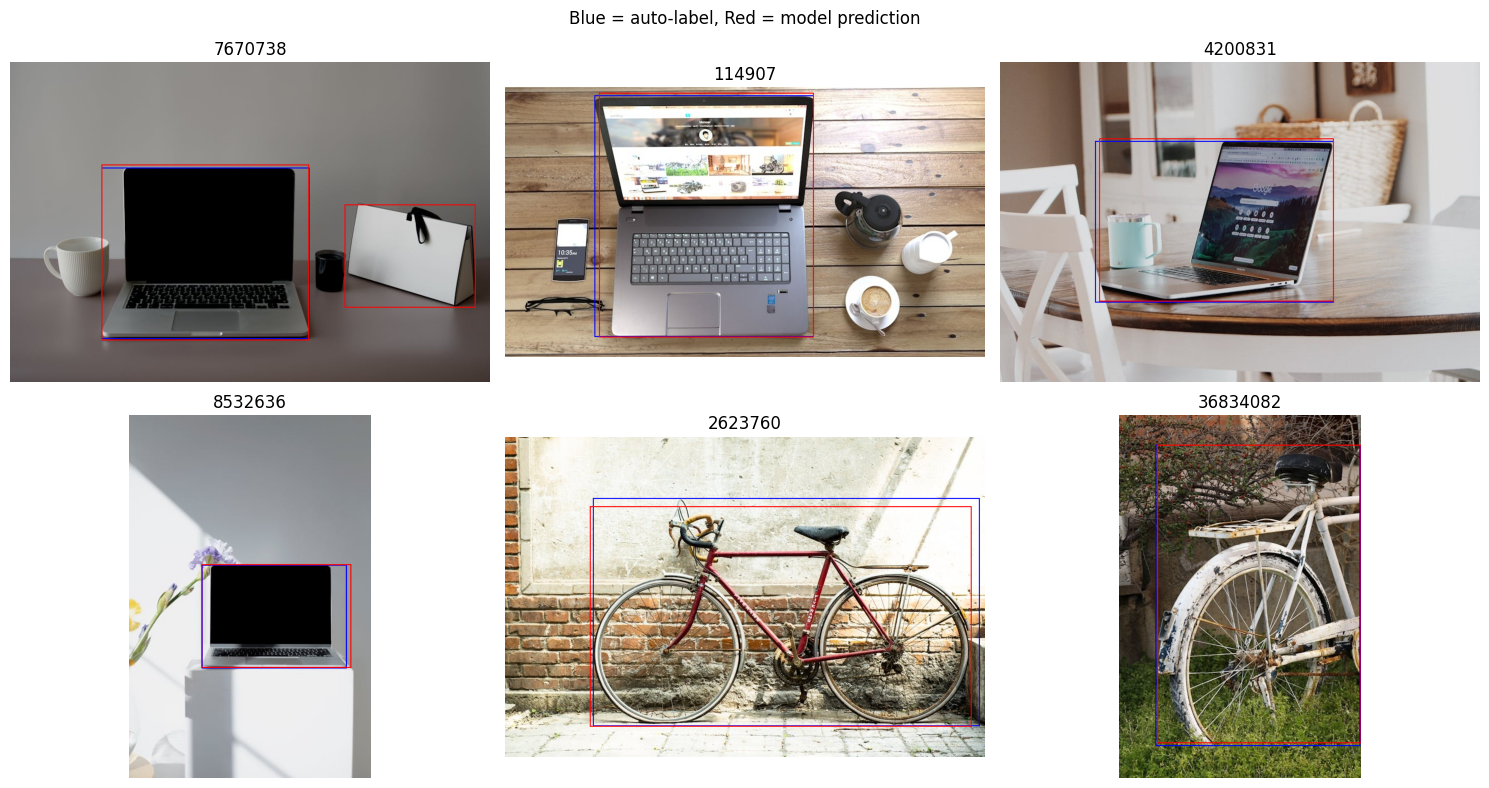

In [17]:
# I am gonna  compare auto labels and model predictions.
val_imgs = sorted((yolo_ds/ "images" / "val").glob("*.jpg"))
sample = random.sample(val_imgs, min(6, len(val_imgs)))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, img_path in zip(axes, sample):
    img= Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(img)
    width, height =img.size

    for line in (yolo_ds / "labels" / "val" / f"{img_path.stem}.txt").read_text().splitlines():
        _, cx, cy, bw, bh = map(float, line.split())
        box = [int((cx - bw / 2)*width),int((cy -bh / 2)*height),int((cx + bw / 2)*width),int((cy + bh / 2)*height)]
        draw.rectangle(box, outline='blue', width=2)
    result = eval_model.predict(str(img_path), conf=0.25, verbose=False)[0]

    for box in result.boxes.xyxy:
        draw.rectangle([int(v) for v in box.tolist()], outline='red', width=2)
    ax.imshow(img)
    ax.set_title(img_path.stem[:20])
    ax.set_axis_off()

for ax in axes[len(sample):]:
    ax.set_axis_off()

plt.suptitle('Blue = auto-label, Red = model prediction', fontsize=12)
plt.tight_layout()
plt.show()
# For debugging, I used QWEN.